In [8]:
# Imports
import os
import sys
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

# Import from wasp package
from wasp.io_ww3 import find_closest_time, load_ww3_spectrum
from wasp.wave_params import calculate_wave_parameters
from wasp.partition import partition_spectrum
from wasp.plotting import plot_directional_spectrum
from wasp.utils import load_config

ImportError: cannot import name 'load_config' from 'wasp.utils' (/Users/jtakeo/googleDrive/myProjects/wasp/venv/lib/python3.12/site-packages/wasp/utils.py)

In [ ]:
# ============================================================================
# LOAD CONFIGURATION
# ============================================================================
CONFIG = load_config('../config.yaml')

# Partitioning parameters (from config.yaml)
MIN_ENERGY_THRESHOLD_FRACTION = CONFIG['partitioning']['ww3']['min_energy_fraction']
MAX_PARTITIONS = CONFIG['partitioning']['ww3']['max_partitions']
THRESHOLD_PERCENTILE = CONFIG['partitioning']['ww3']['threshold_percentile']
MERGE_FACTOR = CONFIG['partitioning']['ww3']['merge_factor']

# Plotting parameters (from config.yaml)
PLOT_PERIOD_MAX = CONFIG['plotting'].get('period_max', 25)

print(f"Configuration loaded:")
print(f"  threshold_percentile = {THRESHOLD_PERCENTILE}")
print(f"  merge_factor = {MERGE_FACTOR}")
print(f"  max_partitions = {MAX_PARTITIONS}")
print(f"  min_energy_fraction = {MIN_ENERGY_THRESHOLD_FRACTION}")

Adaptive threshold: 5.47e-01 (99.0th percentile)
Identifying spectral peaks with threshold: 5.47e-01
Spectrum values: min=2.45e-23, max=1.26e+00, mean=3.20e-02
Identified 1 spectral peaks
Generating mask from ICOD...
  ICOD propagation converged after 3 iterations
Calculating distances between peaks...
Calculating peak spreading...
Checking for overlapping systems (merge_factor=0.6)...
Number of masks: 1
[DEBUG] Sum of partition energies: 0.072308
[DEBUG] Expected total: 0.072308
Total spectrum energy: 0.068694
Sum of partitioned energies: 0.072308

 SPECTRAL PARTITIONING - PROCESS SUMMARY
🔍 Spectral peaks initially identified: 1
🔗 After merging nearby systems: 1 partition(s)
   Partition IDs in mask: [np.int64(1)]

 PARTITIONING RESULTS
Number of partitions found: 1
──────────────────────────────────────────────────────────────────────


NameError: name 'delf' is not defined

/var/folders/cp/8th3fpl14tz3yqc3hyy8bksc0000gq/T/ipykernel_3418/769489025.py:33: UserWarning: The following kwargs were not used by contour: 'label'
  cs = ax2.contour(theta, r, E_part, levels=levels_part,


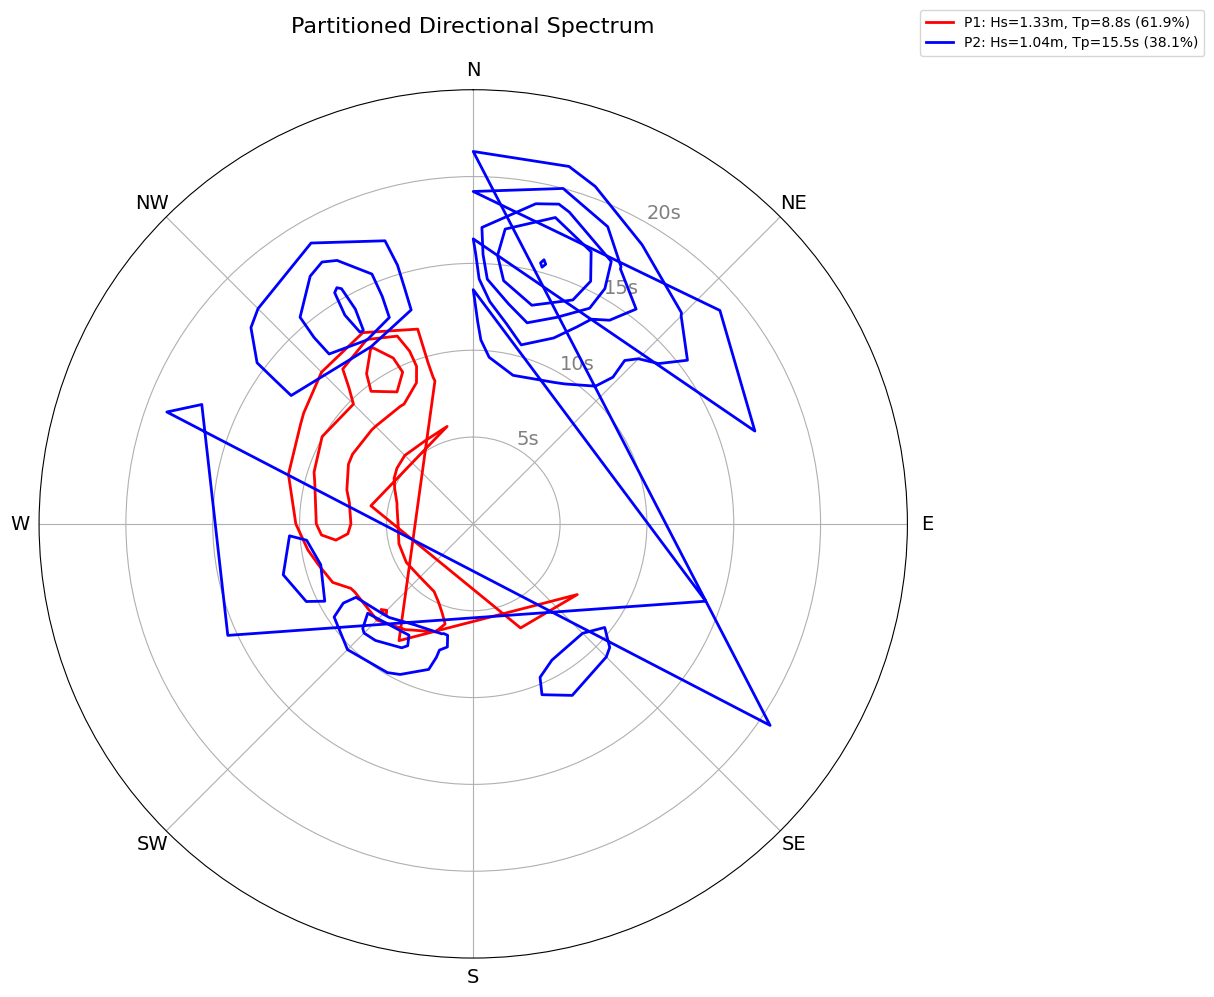

In [ ]:
# ============================================================================
# LOAD WW3 SPECTRUM
# ============================================================================
file_path = '/Users/jtakeo/googleDrive/myProjects/wasp/data/ww3_41001.nc'
itime = 5527
selected_time = pd.to_datetime(xr.open_dataset(file_path).time[itime].values)

# Load spectrum using wasp I/O function
E2d, freq, dirs, dirs_rad, lon, lat, wnd, wnddir = load_ww3_spectrum(file_path, itime)

print(f"File: {os.path.basename(file_path)}")
print(f"Time: {selected_time}")
print(f"Location: lon={lon:.2f}, lat={lat:.2f}")
print(f"Spectrum shape: {E2d.shape} (freq x dir)")

## Spectral Partitioning

In [ ]:
# ============================================================================
# APPLY PARTITIONING (parameters from config.yaml)
# ============================================================================
results = partition_spectrum(
    E2d, freq, dirs_rad,
    threshold_mode='adaptive',
    threshold_percentile=THRESHOLD_PERCENTILE,
    merge_factor=MERGE_FACTOR,
    max_partitions=MAX_PARTITIONS
)

if results is None:
    print("No spectral peaks identified!")
else:
    min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
    n_peaks_initial = len(results['peaks'])
    
    # Count significant partitions
    n_partitions_final = sum(
        1 for i in range(1, len(results['Hs']))
        if results['energy'][i] > min_energy_threshold
    )

    print("\n" + "="*70)
    print(" SPECTRAL PARTITIONING - PROCESS SUMMARY")
    print("="*70)
    print(f"Spectral peaks initially identified: {n_peaks_initial}")
    print(f"After merging nearby systems: {n_partitions_final} partition(s)")
    print("="*70)

    print("\n" + "="*70)
    print(" PARTITIONING RESULTS")
    print("="*70)
    print(f"Number of significant partitions: {n_partitions_final}")
    print("─"*70)

    partition_count = 0
    for i in range(1, len(results['Hs'])):
        if results['energy'][i] > min_energy_threshold:
            partition_count += 1
            energy_pct = (results['energy'][i] / results['total_m0']) * 100
            print(f"\nPartition {partition_count}:")
            print(f"  Hs = {results['Hs'][i]:.2f} m")
            print(f"  Tp = {results['Tp'][i]:.2f} s")
            print(f"  Dp = {results['Dp'][i]:.0f}°")
            print(f"  Energy: {results['energy'][i]:.4f} m² ({energy_pct:.1f}%)")

    print("\n" + "─"*70)
    print(f"Integrated total:")
    print(f"  Hs = {results['total_Hs']:.2f} m")
    print(f"  Tp = {results['total_Tp']:.2f} s")
    print(f"  Dp = {results['total_Dp']:.0f}°")
    print("="*70)

 ANÁLISE DO ESPECTRO 1D - ENERGIA POR PERÍODO

📊 Top 5 picos de energia no espectro 1D:
  1. Período: 15.5s, Frequência: 0.0644Hz, Energia: 2.033542 m²·s
  2. Período: 8.8s, Frequência: 0.1141Hz, Energia: 1.420597 m²·s

──────────────────────────────────────────────────────────────────────
 PARTIÇÕES DETECTADAS PELO ALGORITMO
──────────────────────────────────────────────────────────────────────

Número de partições: 2

Partição 1 (ID=1):
  Hs = 1.33 m
  Tp = 8.76 s ← Período
  Dp = 302°
  Energia = 0.110111 m² (65.1%)

Partição 2 (ID=2):
  Hs = 1.04 m
  Tp = 15.52 s ← Período
  Dp = 68°
  Energia = 0.067771 m² (40.0%)

 💡 DIAGNÓSTICO
Compare os períodos do espectro 1D com os períodos das partições.
Se o sistema de 15s tem muita energia no 1D mas não aparece como
partição principal, pode ser:
  1. threshold_percentile muito BAIXO → detectando ruído como picos
  2. merge_factor muito BAIXO → não mesclando sistemas próximos


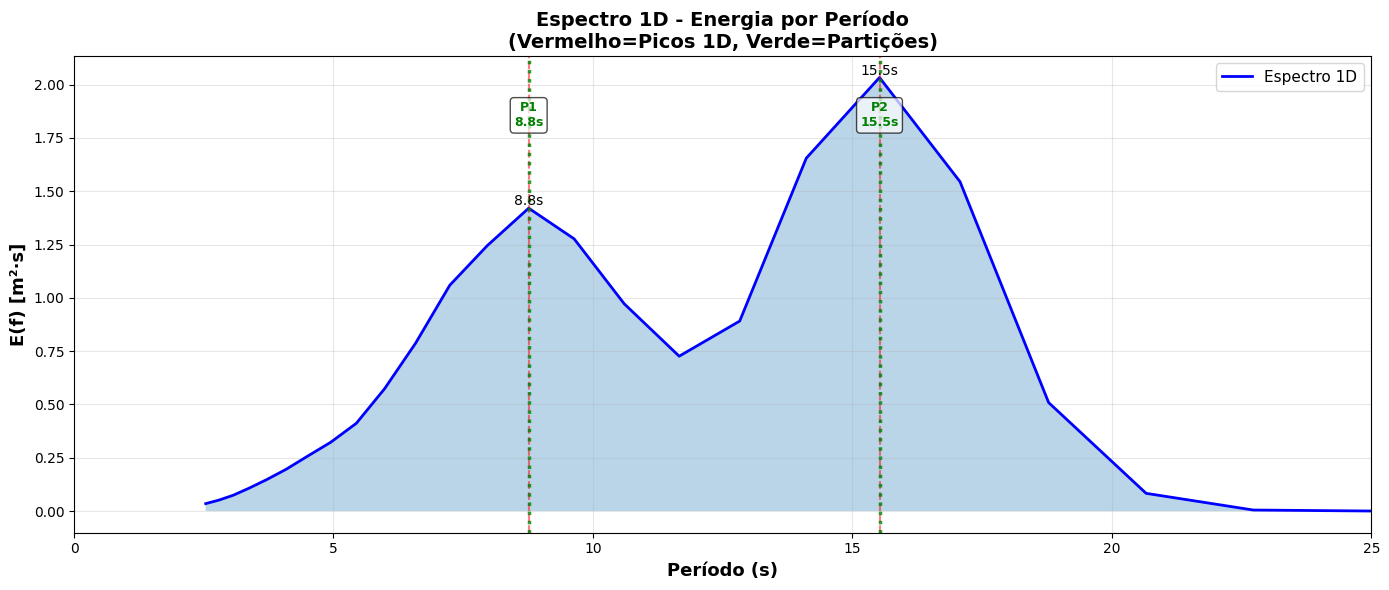

In [ ]:
# ============================================================================
# PLOT: Total directional spectrum
# ============================================================================
hs, tp, dp, m0, delf, ddir, i_peak, j_peak = calculate_wave_parameters(E2d, freq, dirs_rad)

fig, ax = plot_directional_spectrum(
    E2d, freq, dirs,
    selected_time=selected_time,
    hs=hs, tp=tp, dp=dp
)
plt.show()

## Partition Visualization

In [ ]:
# ============================================================================
# PLOT: Individual partitions on polar spectrum
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(12, 10), subplot_kw=dict(projection='polar'))

freq_plot = np.asarray(freq).flatten()
dirs_plot = np.asarray(dirs).flatten()
dirs_rad_plot = np.radians(dirs_plot)

with np.errstate(divide='ignore', invalid='ignore'):
    period = np.where(freq_plot > 0, 1.0 / freq_plot, 0)

theta, r = np.meshgrid(dirs_rad_plot, period)

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']
partition_count = 0
legend_elements = []

for i in range(1, len(results['Hs'])):
    if results['energy'][i] > min_energy_threshold:
        E_part = np.zeros_like(E2d)
        mask = (results['mask'] == i)
        E_part[mask] = E2d[mask]

        levels_part = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
        color = colors[partition_count % len(colors)]
        ax2.contour(theta, r, E_part, levels=levels_part,
                    colors=color, linewidths=2)

        pct = (results['energy'][i] / results['total_m0']) * 100
        label = (f'P{partition_count+1}: Hs={results["Hs"][i]:.2f}m, '
                 f'Tp={results["Tp"][i]:.1f}s, Dp={results["Dp"][i]:.0f}° ({pct:.1f}%)')
        legend_elements.append(Line2D([0], [0], color=color, lw=2, label=label))
        partition_count += 1

ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_rticks([5, 10, 15, 20])
ax2.set_yticklabels(['5s', '10s', '15s', '20s'], color='gray', fontsize=12)
ax2.set_rlim(0, PLOT_PERIOD_MAX)
ax2.set_rlabel_position(30)
ax2.tick_params(axis='y', colors='gray', labelsize=14)

ticks = ['N','NE','E','SE','S','SW','W','NW']
tick_angles = np.deg2rad(np.linspace(0, 315, 8))
ax2.set_xticks(tick_angles)
ax2.set_xticklabels(ticks, fontsize=14)

ax2.set_title('Partitioned Directional Spectrum', fontsize=16, pad=20)
ax2.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

 ANÁLISE DE SPREADING DIRECIONAL

Partição 1 (Tp=8.8s):
  Energia total na freq pico: 1.420597 m²·s·rad⁻¹
  Pico direcional: 0.992041 m²·s·rad⁻¹
  Spreading (80% energia): ~105°
  Fator de concentração: 16.76x
  ⮕ Energia 2D total partição: 0.110111 m²
  ✓ Sistema BEM CONCENTRADO direcionalmente

Partição 2 (Tp=15.5s):
  Energia total na freq pico: 2.033542 m²·s·rad⁻¹
  Pico direcional: 5.174153 m²·s·rad⁻¹
  Spreading (80% energia): ~30°
  Fator de concentração: 61.07x
  ⮕ Energia 2D total partição: 0.067771 m²
  ✓ Sistema BEM CONCENTRADO direcionalmente

 💡 EXPLICAÇÃO
Um sistema pode ter:
  • Alto pico no espectro 1D (muita energia total)
  • MAS espalhado em muitas direções (baixa concentração)
  ⮕ Resultado: Energia 2D da partição MENOR

Outro sistema:
  • Pico menor no espectro 1D
  • MAS muito concentrado em poucas direções (alta concentração)
  ⮕ Resultado: Energia 2D da partição MAIOR


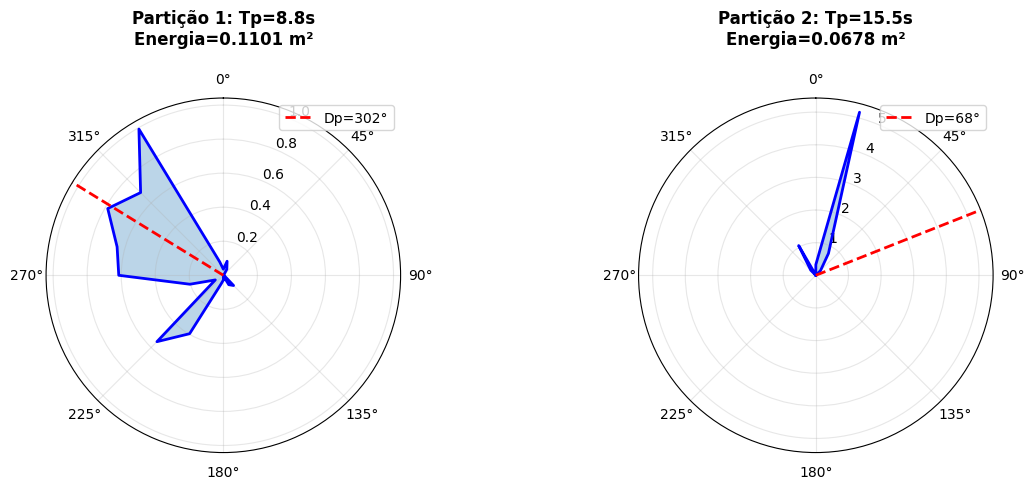


💡 Observe:
  • Sistema mais ESPALHADO → mesma energia dividida em muitas direções
  • Sistema mais CONCENTRADO → energia concentrada em poucas direções
  ⮕ O algoritmo de particionamento privilegia sistemas CONCENTRADOS


In [ ]:
## Save Results to CSV

# ============================================================================
# SAVE PARTITION RESULTS (same format as 02_partition_ww3.py)
# ============================================================================
output_dir = f'../data/partition-ww3-{THRESHOLD_PERCENTILE}-{MERGE_FACTOR}'
os.makedirs(output_dir, exist_ok=True)

ref_id = 'example'
min_energy_threshold = MIN_ENERGY_THRESHOLD_FRACTION * results['total_m0']

moments = results['moments']
m0_total = moments['total'][0]
m1_total = moments['total'][1]
m2_total = moments['total'][2]

data = {
    'reference_id': ref_id,
    'obs_time': selected_time,
    'longitude': float(lon),
    'latitude': float(lat),
    'source_file': os.path.basename(file_path),
    
    # Total spectrum
    'total_energy': results['total_m0'],
    'total_Hs': results['total_Hs'],
    'total_Tp': results['total_Tp'],
    'total_Dp': results['total_Dp'],
    'total_m0': m0_total,
    'total_m1': m1_total,
    'total_m2': m2_total,
}

# Add partition data (up to 3 partitions)
partition_idx = 0
for i in range(1, len(results['Hs'])):
    if results['energy'][i] > min_energy_threshold:
        partition_idx += 1
        if partition_idx > 3:
            break
        data[f'P{partition_idx}_energy'] = results['energy'][i]
        data[f'P{partition_idx}_Hs'] = results['Hs'][i]
        data[f'P{partition_idx}_Tp'] = results['Tp'][i]
        data[f'P{partition_idx}_Dp'] = results['Dp'][i]
        data[f'P{partition_idx}_m0'] = moments['m0'][i]
        data[f'P{partition_idx}_m1'] = moments['m1'][i]
        data[f'P{partition_idx}_m2'] = moments['m2'][i]

# Fill remaining partitions with zeros
for p in range(partition_idx + 1, 4):
    for key in ['energy', 'Hs', 'Tp', 'Dp', 'm0', 'm1', 'm2']:
        data[f'P{p}_{key}'] = 0.0

# Add wind data
data['wnd'] = float(wnd) if wnd is not None else np.nan
data['wnddir'] = float(wnddir) if wnddir is not None else np.nan

# Save
date_str = selected_time.strftime('%Y%m%d-%H%M%S')
output_filename = f'ww3_{ref_id}_{date_str}.csv'
output_path = os.path.join(output_dir, output_filename)

df_results = pd.DataFrame([data])
df_results.to_csv(output_path, index=False, float_format='%.6f')

print(f"Results saved to: {output_path}")
print(f"\nColumns: {list(df_results.columns)}")
print(f"\nPreview:")
df_results.T